In [69]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

sns.set_theme(style="whitegrid")

In [70]:
class Dataset:

    def __init__(self, filepath):
        self.filepath = filepath
        self.df = None

    def load(self):
        self.df = pd.read_csv(self.filepath)
        print("Shape :", self.df.shape)
        return self.df

    def head(self, n=5):
        return self.df.head(n)

    def info(self):
        return self.df.info()

    def missing_values(self):
        return self.df.isnull().sum()

    def churn_distribution(self):
        return (
            self.df["Exited"].value_counts(normalize=True)* 100
        )

In [71]:
class Preprocessor:

    def __init__(self, df):

        self.df = df.copy()

        self.X = None
        self.y = None

        self.X_train = None
        self.X_test = None

        self.y_train = None
        self.y_test = None

        self.scaler = None

        self.X_train_scaled = None
        self.X_test_scaled = None

    def clean_data(self):

        self.df = self.df.drop(
            columns=[
                "RowNumber",
                "CustomerId",
                "Surname",
                "NumOfProducts",
                "IsActiveMember"
            ]
        )

        self.df = pd.get_dummies(
            self.df,
            columns=[
                "Geography",
                "Gender"
            ],
            drop_first=True
        )

        for col in self.df.columns:

            if self.df[col].dtype == bool:

                self.df[col] = (
                    self.df[col]
                    .astype(int)
                )

        return self.df

    def split(self):

        self.X = self.df.drop(
            "Exited",
            axis=1
        )

        self.y = self.df["Exited"]

        (
            self.X_train,
            self.X_test,
            self.y_train,
            self.y_test
        ) = train_test_split(
            self.X,
            self.y,
            test_size=0.20,
            random_state=42,
            stratify=self.y
        )

        return (
            self.X_train,
            self.X_test,
            self.y_train,
            self.y_test
        )

    def scale(self):

        self.scaler = StandardScaler()

        self.X_train_scaled = (
            self.scaler.fit_transform(
                self.X_train
            )
        )

        self.X_test_scaled = (
            self.scaler.transform(
                self.X_test
            )
        )

        return (
            self.X_train_scaled,
            self.X_test_scaled
        )

In [72]:
class LogisticRegressionModel:

    def __init__(self):

        self.model = LogisticRegression(
            random_state=42,
            max_iter=1000
        )

        self.y_pred = None
        self.y_prob = None
        self.z_score = None

    def fit(self, X_train, y_train):
        self.model.fit(X_train, y_train)
        return self

    def predict(
        self,
        X_test
    ):

        self.y_pred = (
            self.model.predict(X_test)
        )

        self.y_prob = (
            self.model.predict_proba(X_test)
            [:,1]
        )

        self.z_score = (
            self.model.decision_function(
                X_test
            )
        )

        return (
            self.y_pred,
            self.y_prob,
            self.z_score
        )

    def coefficients(self, feature_names):
        coef_df = pd.DataFrame({
            "Feature": feature_names,
            "Coefficient":
            self.model.coef_[0]
        })

        return coef_df.sort_values(
            by="Coefficient",
            ascending=False
        )

    def odds_ratio(
        self,
        feature_names
    ):

        odds_df = pd.DataFrame({
            "Feature": feature_names,
            "Odds Ratio":
            np.exp(
                self.model.coef_[0]
            )
        })

        return odds_df.sort_values(
            by="Odds Ratio",
            ascending=False
        )

    def intercept(self):

        return self.model.intercept_[0]

In [73]:
class Evaluation:

    @staticmethod
    def metrics(
        y_true,
        y_pred
    ):

        return pd.DataFrame({

            "Metric": [
                "Accuracy",
                "Precision",
                "Recall",
                "F1 Score"
            ],

            "Value": [
                accuracy_score(y_true, y_pred),
                precision_score(y_true, y_pred),
                recall_score(y_true, y_pred),
                f1_score(y_true, y_pred)
            ]
        })

    @staticmethod
    def report(
        y_true,
        y_pred
    ):

        return classification_report(
            y_true,
            y_pred
        )

    @staticmethod
    def confusion(
        y_true,
        y_pred
    ):

        return confusion_matrix(
            y_true,
            y_pred
        )

In [74]:
class Visualization:

    @staticmethod
    def show_all(
        df,
        z_score,
        y_prob,
        y_test,
        cm,
        coef_df
    ):

        plt.figure(figsize=(6,4))
        sns.countplot(x=df["Exited"])
        plt.title("Distribusi Customer Churn")
        plt.show()


        z = np.linspace(-10,10,1000)
        sigmoid = 1/(1+np.exp(-z))

        plt.figure(figsize=(8,5))
        plt.plot(z,sigmoid)
        plt.title("Sigmoid Function")
        plt.show()

        plt.figure(figsize=(8,5))
        plt.scatter(
            z_score,
            y_prob,
            alpha=0.4
        )
        plt.title(
            "Sigmoid Transformation"
        )
        plt.show()

        # Confusion Matrix
        plt.figure(figsize=(6,5))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues"
        )
        plt.show()

        # Precision Recall Curve
        precision_curve, recall_curve, _ = (
            precision_recall_curve(
                y_test,
                y_prob
            )
        )

        plt.figure(figsize=(8,5))
        plt.plot(
            recall_curve,
            precision_curve
        )
        plt.show()

        # Coefficient Plot
        plt.figure(figsize=(10,6))
        sns.barplot(
            data=coef_df,
            x="Coefficient",
            y="Feature"
        )
        plt.show()

In [75]:
if __name__ == "__main__":

    data = Dataset(
        "Churn_Modelling.csv"
    )

    df = data.load()

    prep = Preprocessor(df)

    prep.clean_data()

    prep.split()

    model = LogisticRegressionModel()

    prep.scale()

    model.fit(
        prep.X_train_scaled,
        prep.y_train
    )

    (
        y_pred,
        y_prob,
        z_score
    ) = model.predict(
        prep.X_test_scaled
    )

    metrics_df = Evaluation.metrics(
        prep.y_test,
        y_pred,
    )

    report = Evaluation.report(
        prep.y_test,
        y_pred
    )

    cm = Evaluation.confusion(
        prep.y_test,
        y_pred
    )

    coef_df = model.coefficients(
        prep.X.columns
    )

    odds_df = model.odds_ratio(
        prep.X.columns
    )

    print(metrics_df)

    print(report)

    display(coef_df)

    display(odds_df)

Shape : (10000, 14)
      Metric     Value
0   Accuracy  0.790000
1  Precision  0.431579
2     Recall  0.100737
3   F1 Score  0.163347
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      1593
           1       0.43      0.10      0.16       407

    accuracy                           0.79      2000
   macro avg       0.62      0.53      0.52      2000
weighted avg       0.73      0.79      0.73      2000



,Feature,Coefficient
1,Age,0.651766
6,Geography_Germany,0.348937
3,Balance,0.177388
5,EstimatedSalary,0.048761
7,Geography_Spain,0.012177
2,Tenure,-0.004285
4,HasCrCard,-0.026334
0,CreditScore,-0.097087
8,Gender_Male,-0.268325


,Feature,Odds Ratio
1,Age,1.918927
6,Geography_Germany,1.417559
3,Balance,1.194094
5,EstimatedSalary,1.049969
7,Geography_Spain,1.012251
2,Tenure,0.995724
4,HasCrCard,0.974010
0,CreditScore,0.907477
8,Gender_Male,0.764659


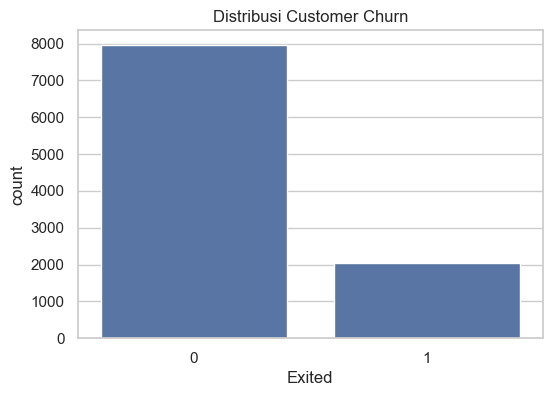

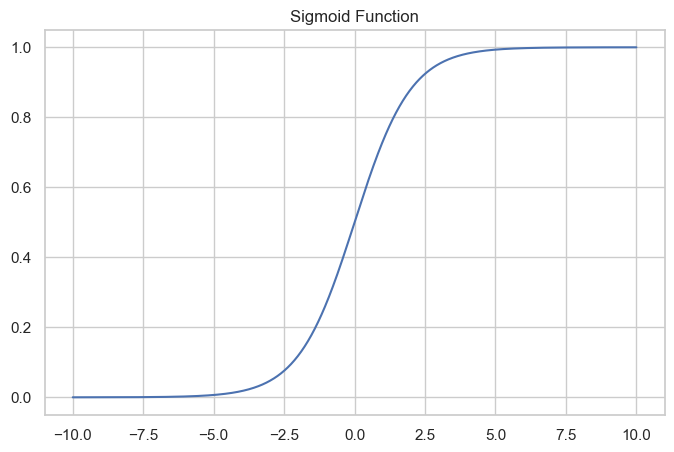

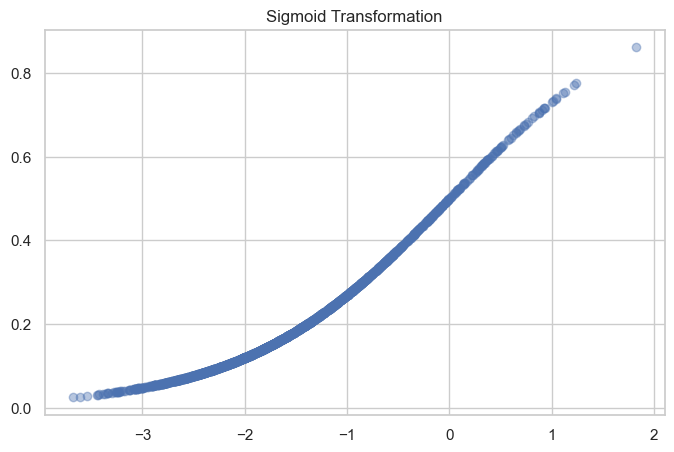

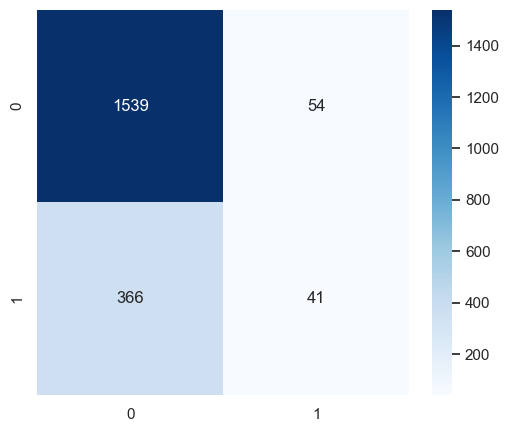

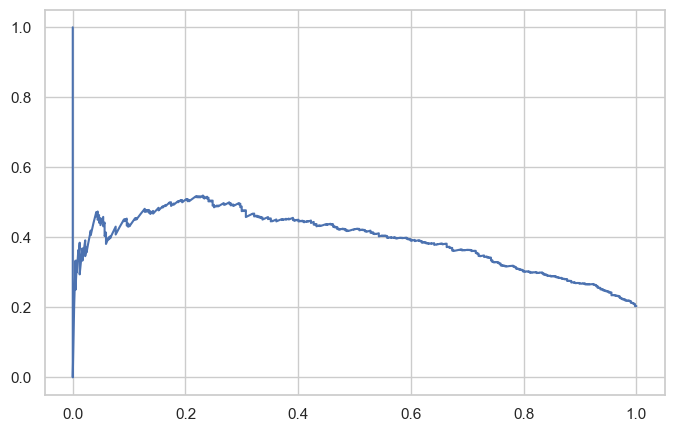

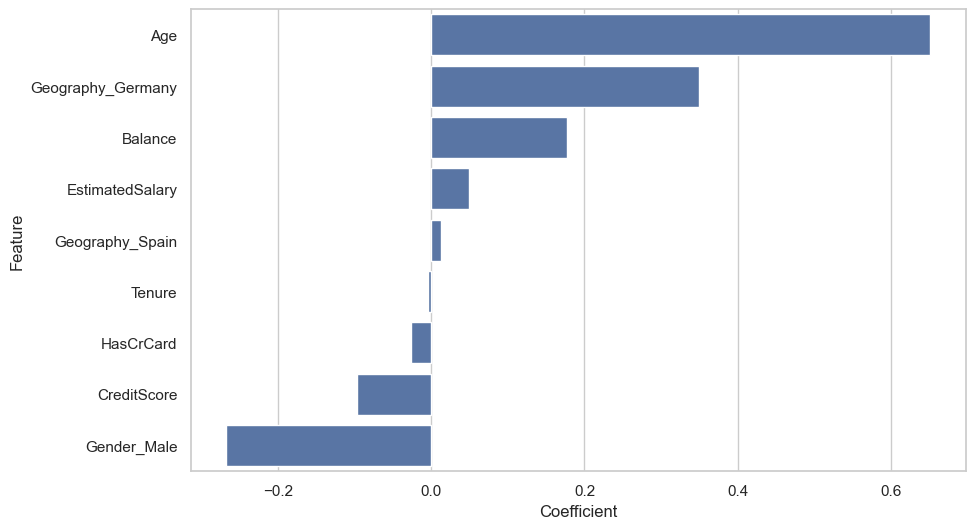

In [76]:
if __name__ == "__main__":

    Visualization.show_all(
        df,
        z_score,
        y_prob,
        prep.y_test,
        cm,
        coef_df
    )

In [77]:
from imblearn.over_sampling import SMOTE

In [78]:
class SmoteProcessor:

    def __init__(
        self,
        X_train,
        y_train,
        random_state=42
    ):

        self.X_train = X_train
        self.y_train = y_train

        self.random_state = random_state

        self.smote = SMOTE(
            random_state=self.random_state
        )

        self.X_train_smote = None
        self.y_train_smote = None

    def apply(self):

        (
            self.X_train_smote,
            self.y_train_smote
        ) = self.smote.fit_resample(
            self.X_train,
            self.y_train
        )

        return (
            self.X_train_smote,
            self.y_train_smote
        )

    def distribution(self):

        print("Sebelum SMOTE")
        print(pd.Series(self.y_train).value_counts())

        print()

        print("Sesudah SMOTE")
        print(pd.Series(self.y_train_smote).value_counts())

In [79]:
model = LogisticRegressionModel()

model.fit(
    prep.X_train_scaled,
    prep.y_train
)

(
    y_pred,
    y_prob,
    z_score
) = model.predict(
    prep.X_test_scaled
)

In [80]:
smote = SmoteProcessor(
    prep.X_train_scaled,
    prep.y_train
)

(
    X_train_smote,
    y_train_smote
) = smote.apply()

smote.distribution()

Sebelum SMOTE
Exited
0    6370
1    1630
Name: count, dtype: int64

Sesudah SMOTE
Exited
1    6370
0    6370
Name: count, dtype: int64


In [81]:
model_smote = LogisticRegressionModel()

model_smote.fit(
    X_train_smote,
    y_train_smote
)

(
    y_pred_smote,
    y_prob_smote,
    z_score_smote
) = model_smote.predict(
    prep.X_test_scaled
)

In [82]:
metrics_smote = Evaluation.metrics(
    prep.y_test,
    y_pred_smote
)

report_smote = Evaluation.report(
    prep.y_test,
    y_pred_smote
)

cm_smote = Evaluation.confusion(
    prep.y_test,
    y_pred_smote
)

coef_smote = model_smote.coefficients(
    prep.X.columns
)

odds_smote = model_smote.odds_ratio(
    prep.X.columns
)

In [83]:
print("=== Logistic Regression ===")
print(metrics_df)

print()

print("=== Logistic Regression + SMOTE ===")
print(metrics_smote)

=== Logistic Regression ===
      Metric     Value
0   Accuracy  0.790000
1  Precision  0.431579
2     Recall  0.100737
3   F1 Score  0.163347

=== Logistic Regression + SMOTE ===
      Metric     Value
0   Accuracy  0.707000
1  Precision  0.378562
2     Recall  0.685504
3   F1 Score  0.487762


In [84]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Before SMOTE":metrics_df["Value"],

    "After SMOTE":metrics_smote["Value"]

})

display(comparison)

,Metric,Before SMOTE,After SMOTE
0,Accuracy,0.790000,0.707000
1,Precision,0.431579,0.378562
2,Recall,0.100737,0.685504
3,F1 Score,0.163347,0.487762


In [85]:
class ClassWeightLogisticRegressionModel:

    def __init__(self):

        self.model = LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        )

        self.y_pred = None
        self.y_prob = None
        self.z_score = None

    def fit(self, X_train, y_train):

        self.model.fit(
            X_train,
            y_train
        )

        return self

    def predict(self, X_test):

        self.y_pred = self.model.predict(
            X_test
        )

        self.y_prob = self.model.predict_proba(
            X_test
        )[:,1]

        self.z_score = self.model.decision_function(
            X_test
        )

        return (
            self.y_pred,
            self.y_prob,
            self.z_score
        )

    def coefficients(self, feature_names):

        coef_df = pd.DataFrame({

            "Feature":feature_names,

            "Coefficient":
            self.model.coef_[0]

        })

        return coef_df.sort_values(
            by="Coefficient",
            ascending=False
        )

    def odds_ratio(self, feature_names):

        odds_df = pd.DataFrame({

            "Feature":feature_names,

            "Odds Ratio":
            np.exp(
                self.model.coef_[0]
            )

        })

        return odds_df.sort_values(
            by="Odds Ratio",
            ascending=False
        )

In [86]:
class SmoteTomekProcessor:

    def __init__(
        self,
        X_train,
        y_train,
        random_state=42
    ):

        self.X_train = X_train
        self.y_train = y_train

        self.smote_tomek = SMOTETomek(
            random_state=random_state
        )

        self.X_train_resampled = None
        self.y_train_resampled = None

    def apply(self):

        (
            self.X_train_resampled,
            self.y_train_resampled
        ) = self.smote_tomek.fit_resample(
            self.X_train,
            self.y_train
        )

        return (
            self.X_train_resampled,
            self.y_train_resampled
        )

    def distribution(self):

        print("Sebelum SMOTE + Tomek")

        print(
            pd.Series(
                self.y_train
            ).value_counts()
        )

        print()

        print("Sesudah SMOTE + Tomek")

        print(
            pd.Series(
                self.y_train_resampled
            ).value_counts()
        )

In [87]:
model_class_weight = ClassWeightLogisticRegressionModel()

model_class_weight.fit(
    prep.X_train_scaled,
    prep.y_train
)

(
    y_pred_class_weight,
    y_prob_class_weight,
    z_score_class_weight
) = model_class_weight.predict(
    prep.X_test_scaled
)

metrics_class_weight = Evaluation.metrics(
    prep.y_test,
    y_pred_class_weight
)

print()

print("=== Logistic Regression + Class Weight ===")

print(metrics_class_weight)


=== Logistic Regression + Class Weight ===
      Metric     Value
0   Accuracy  0.707500
1  Precision  0.380054
2     Recall  0.692875
3   F1 Score  0.490862


In [88]:
smote_tomek = SmoteTomekProcessor(

    prep.X_train_scaled,

    prep.y_train

)

(
    X_train_smote_tomek,
    y_train_smote_tomek
) = smote_tomek.apply()

smote_tomek.distribution()

model_smote_tomek = LogisticRegressionModel()

model_smote_tomek.fit(

    X_train_smote_tomek,

    y_train_smote_tomek

)

(
    y_pred_smote_tomek,

    y_prob_smote_tomek,

    z_score_smote_tomek

) = model_smote_tomek.predict(

    prep.X_test_scaled

)

metrics_smote_tomek = Evaluation.metrics(

    prep.y_test,

    y_pred_smote_tomek

)

print()

print("=== Logistic Regression + SMOTE + Tomek ===")

print(metrics_smote_tomek)

Sebelum SMOTE + Tomek
Exited
0    6370
1    1630
Name: count, dtype: int64

Sesudah SMOTE + Tomek
Exited
1    6219
0    6219
Name: count, dtype: int64

=== Logistic Regression + SMOTE + Tomek ===
      Metric     Value
0   Accuracy  0.709000
1  Precision  0.380301
2     Recall  0.683047
3   F1 Score  0.488576


In [89]:
comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Baseline":

    metrics_df["Value"],

    "SMOTE":

    metrics_smote["Value"],

    "Class Weight":

    metrics_class_weight["Value"],

    "SMOTE + Tomek":

    metrics_smote_tomek["Value"]

})

print()

print("==================== HASIL PERBANDINGAN ====================")

display(comparison)


==================== HASIL PERBANDINGAN ====================


,Metric,Baseline,SMOTE,Class Weight,SMOTE + Tomek
0,Accuracy,0.790000,0.707000,0.707500,0.709000
1,Precision,0.431579,0.378562,0.380054,0.380301
2,Recall,0.100737,0.685504,0.692875,0.683047
3,F1 Score,0.163347,0.487762,0.490862,0.488576


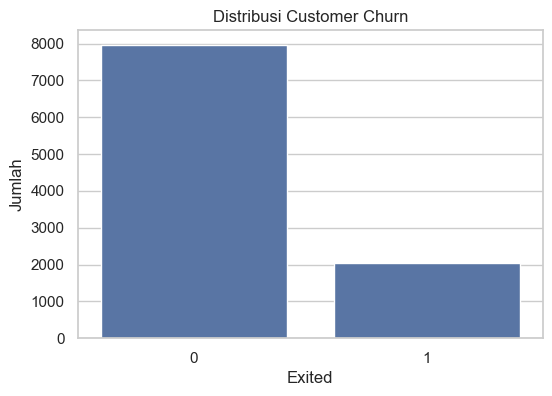

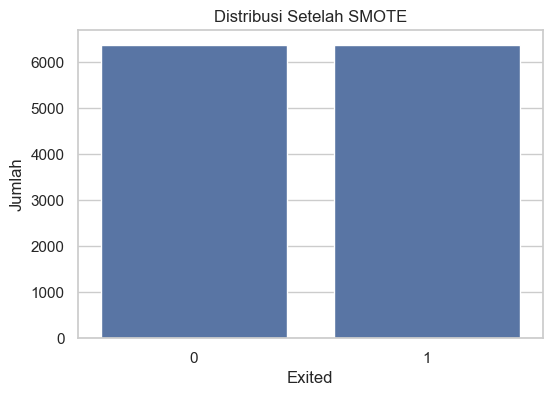

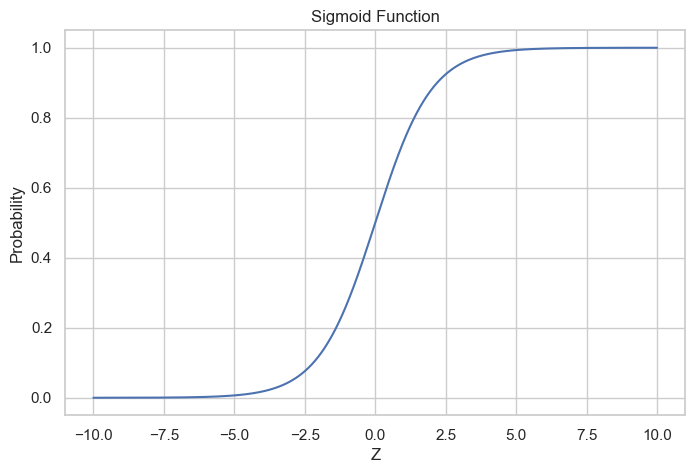

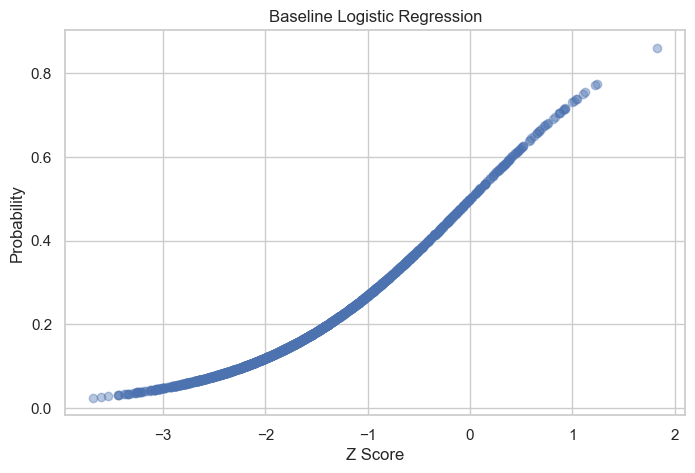

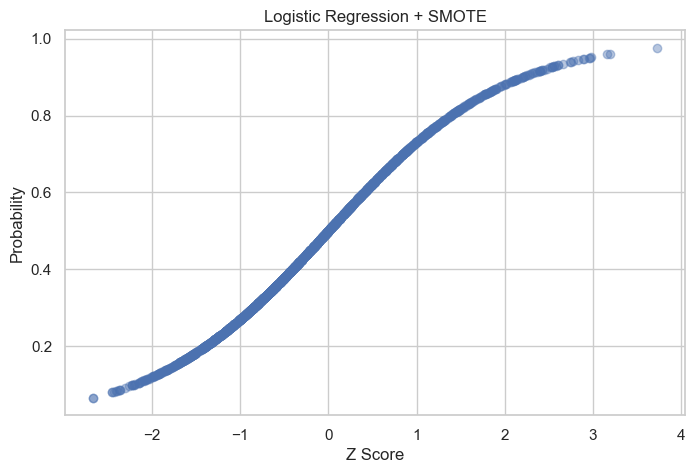

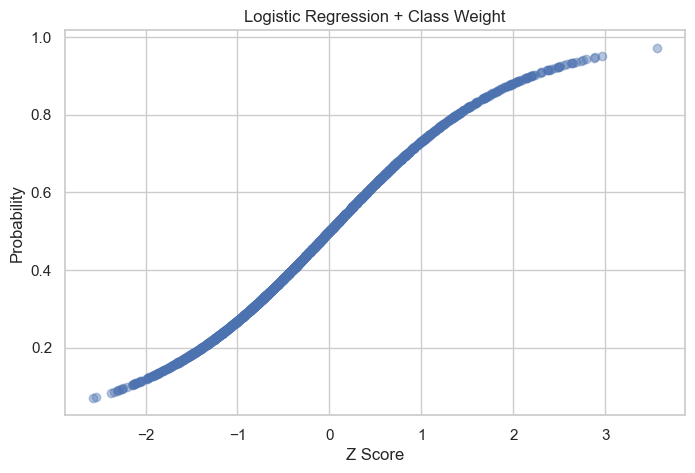

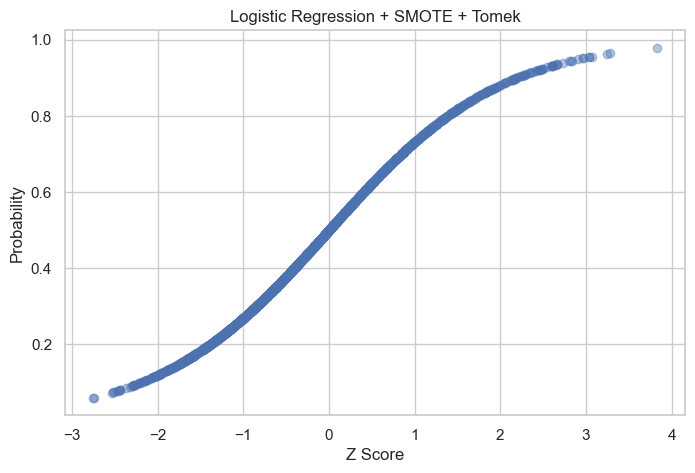

In [90]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Exited"])
plt.title("Distribusi Customer Churn")
plt.xlabel("Exited")
plt.ylabel("Jumlah")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x=y_train_smote)
plt.title("Distribusi Setelah SMOTE")
plt.xlabel("Exited")
plt.ylabel("Jumlah")
plt.show()

z = np.linspace(-10,10,1000)

sigmoid = 1/(1+np.exp(-z))

plt.figure(figsize=(8,5))
plt.plot(z,sigmoid)
plt.title("Sigmoid Function")
plt.xlabel("Z")
plt.ylabel("Probability")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    z_score,
    y_prob,
    alpha=0.4
)

plt.title("Baseline Logistic Regression")
plt.xlabel("Z Score")
plt.ylabel("Probability")

plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    z_score_smote,
    y_prob_smote,
    alpha=0.4
)

plt.title("Logistic Regression + SMOTE")

plt.xlabel("Z Score")

plt.ylabel("Probability")

plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    z_score_class_weight,
    y_prob_class_weight,
    alpha=0.4
)

plt.title("Logistic Regression + Class Weight")

plt.xlabel("Z Score")

plt.ylabel("Probability")

plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    z_score_smote_tomek,
    y_prob_smote_tomek,
    alpha=0.4
)

plt.title("Logistic Regression + SMOTE + Tomek")

plt.xlabel("Z Score")

plt.ylabel("Probability")

plt.show()



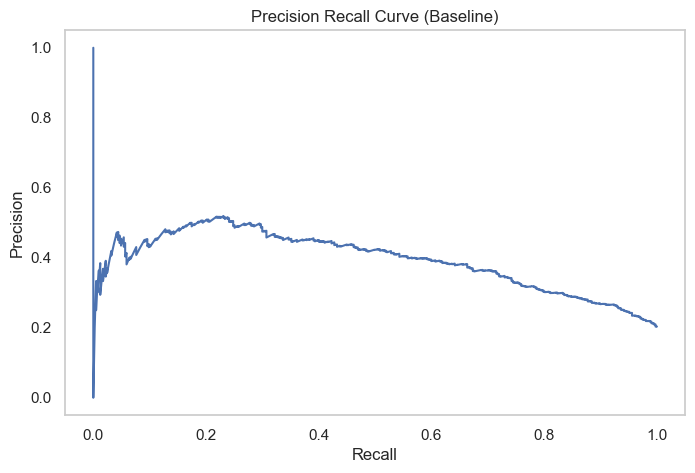

In [91]:
precision, recall, _ = precision_recall_curve(
    prep.y_test,
    y_prob
    )

plt.figure(figsize=(8,5))

plt.plot(recall,precision)

plt.title("Precision Recall Curve (Baseline)")

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.grid()

plt.show()

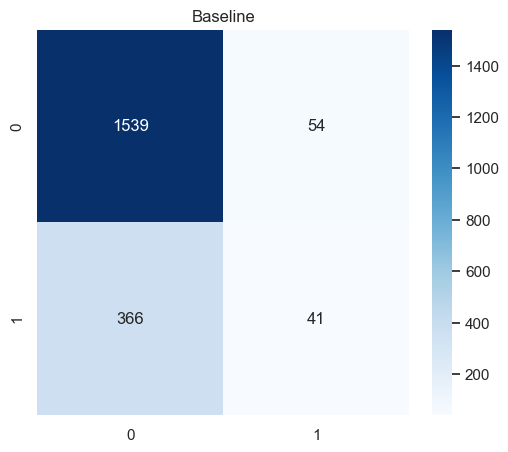

In [92]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Baseline")

plt.show()

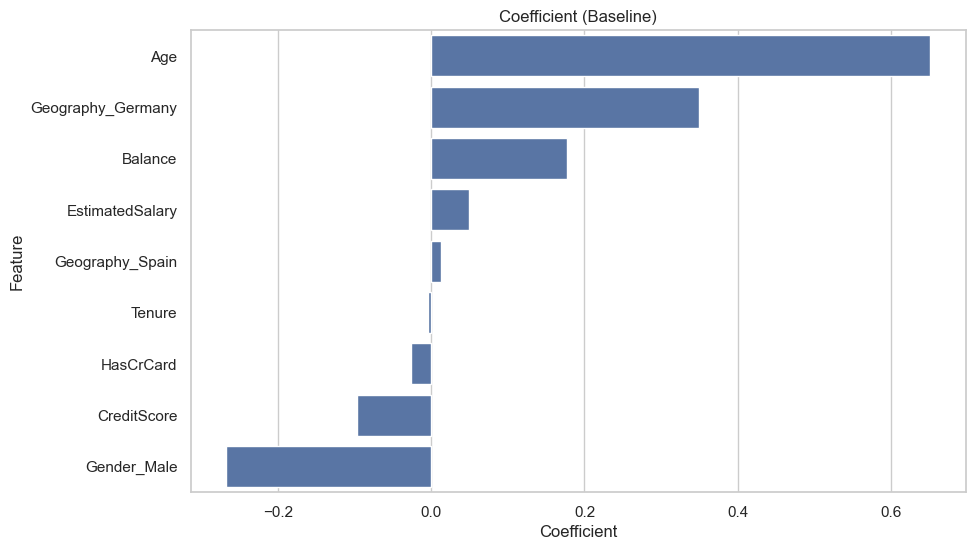

In [96]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Feature"
)

plt.title("Coefficient (Baseline)")

plt.show()

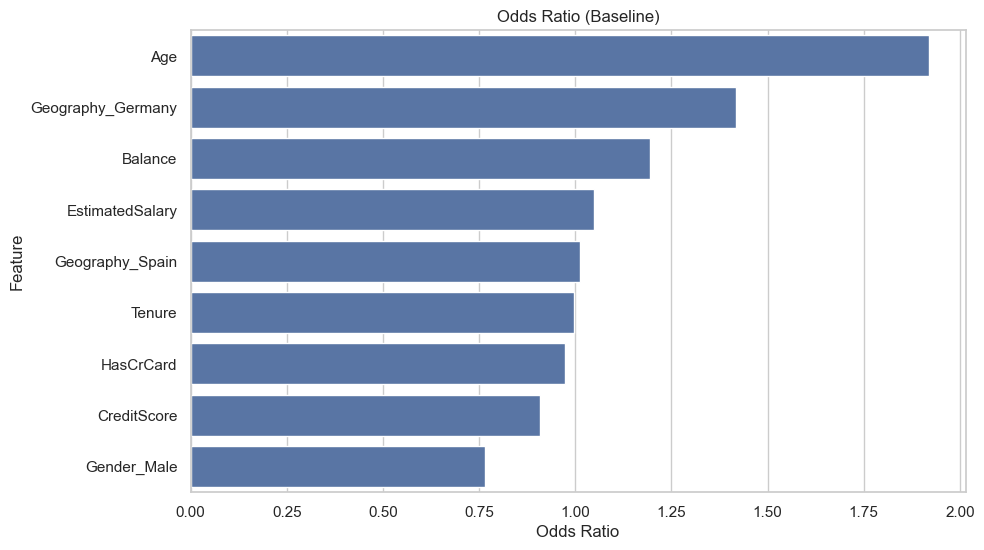

In [97]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=odds_df,
    x="Odds Ratio",
    y="Feature"
)

plt.title("Odds Ratio (Baseline)")

plt.show()

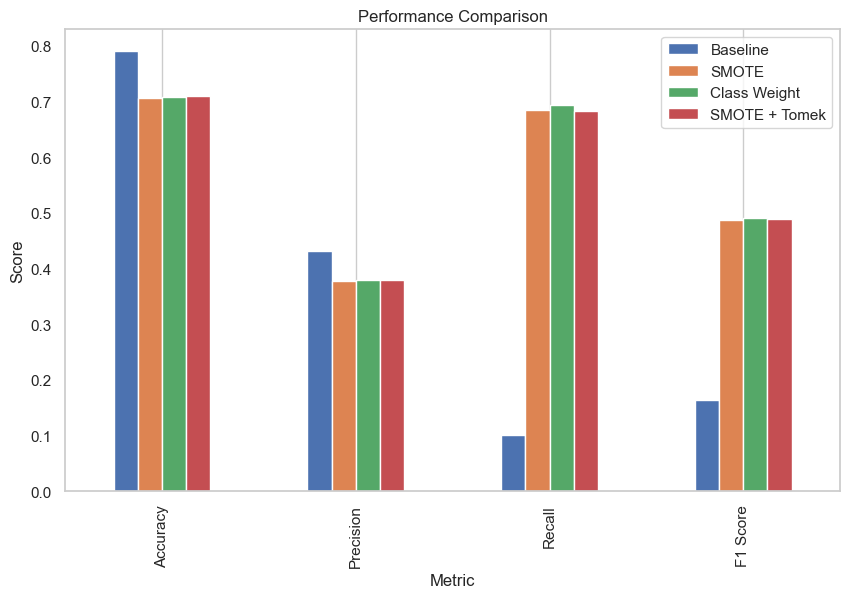

In [98]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Baseline":metrics_df["Value"],

    "SMOTE":metrics_smote["Value"],

    "Class Weight":metrics_class_weight["Value"],

    "SMOTE + Tomek":metrics_smote_tomek["Value"]

})

comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Score")

plt.title("Performance Comparison")

plt.grid(axis="y")

plt.show()